In [ ]:
# Installing the necessary libraries

In [ ]:
pip install ultralytics opencv-python librosa numpy moviepy tensorflow tensorflow-hub

In [ ]:

# Making necessary imports
import os
from pathlib import Path
from typing import List, Dict, Tuple, Optional
import json
import cv2
import numpy as np
import librosa
from scipy.signal import find_peaks
from ultralytics import YOLO
import tensorflow as tf
import tensorflow_hub as hub
from scipy.optimize import linear_sum_assignment
import matplotlib.pyplot as plt

# -----------------------------
# UTIL: Simple IOU and tracker
# -----------------------------

def iou(boxA, boxB):
    # boxes in [x1,y1,x2,y2]
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])
    interArea = max(0, xB - xA) * max(0, yB - yA)
    boxAArea = max(0, boxA[2]-boxA[0]) * max(0, boxA[3]-boxA[1])
    boxBArea = max(0, boxB[2]-boxB[0]) * max(0, boxB[3]-boxB[1])
    if boxAArea + boxBArea - interArea == 0:
        return 0.0
    return interArea / float(boxAArea + boxBArea - interArea)

# Tracking not just for detecting but for tracking objects over the frames
class SimpleTracker:
    """A lightweight IOU-based tracker that assigns persistent IDs
    """

    def __init__(self, iou_threshold: float = 0.3, max_lost: int = 30):
        self.next_id = 0
        self.tracks = {}  # id -> {'bbox': bbox, 'lost': int, 'history': [(frame, bbox)]}
        self.iou_threshold = iou_threshold
        self.max_lost = max_lost

    def update(self, detections: List[np.ndarray], frame_idx: int, classes: List[int], confs: List[float]):
        # detections: list of [x1,y1,x2,y2]
        assigned_ids = []
        if len(self.tracks) == 0:
            # create tracks for all detections
            for d, c, conf in zip(detections, classes, confs):
                tid = self.next_id
                self.next_id += 1
                self.tracks[tid] = {'bbox': d, 'lost': 0, 'history': [(frame_idx, d.tolist(), int(c), float(conf))]}
                assigned_ids.append(tid)
            return assigned_ids

        # compute IoU matrix between existing tracks and detections
        track_ids = list(self.tracks.keys())
        track_boxes = [self.tracks[tid]['bbox'] for tid in track_ids]
        if len(detections) == 0:
            # all tracks increase lost
            for tid in track_ids:
                self.tracks[tid]['lost'] += 1
            # remove lost tracks
            remove = [tid for tid, t in self.tracks.items() if t['lost'] > self.max_lost]
            for r in remove:
                del self.tracks[r]
            return []

        iou_matrix = np.zeros((len(track_boxes), len(detections)), dtype=np.float32)
        for i, tb in enumerate(track_boxes):
            for j, db in enumerate(detections):
                iou_matrix[i, j] = iou(tb, db)

        # Hungarian on negative IoU (maximize IoU)
        row_idx, col_idx = linear_sum_assignment(-iou_matrix)

        matched_tracks = set()
        matched_dets = set()
        for r, c in zip(row_idx, col_idx):
            if iou_matrix[r, c] >= self.iou_threshold:
                tid = track_ids[r]
                self.tracks[tid]['bbox'] = detections[c]
                self.tracks[tid]['lost'] = 0
                self.tracks[tid]['history'].append((frame_idx, detections[c].tolist(), int(classes[c]), float(confs[c])))
                assigned_ids.append(tid)
                matched_tracks.add(r)
                matched_dets.add(c)

        # Create new tracks for unmatched detections
        for det_idx in range(len(detections)):
            if det_idx not in matched_dets:
                tid = self.next_id
                self.next_id += 1
                self.tracks[tid] = {'bbox': detections[det_idx], 'lost': 0, 'history': [(frame_idx, detections[det_idx].tolist(), int(classes[det_idx]), float(confs[det_idx]))]}
                assigned_ids.append(tid)

        # Increment lost for unmatched tracks
        for t_i, tid in enumerate(track_ids):
            if t_i not in matched_tracks:
                self.tracks[tid]['lost'] += 1

        # Remove old tracks
        remove = [tid for tid, t in self.tracks.items() if t['lost'] > self.max_lost]
        for r in remove:
            del self.tracks[r]

        return assigned_ids


# -----------------------------
# Audio Analyzer (YAMNet + fallback)
# -----------------------------

# Audio Analyzer class for classification by sound.
class AudioAnalyzer:
    def __init__(self, alert_labels: Optional[List[str]] = None, alert_confidence: float = 0.6):
        # alert_labels: classes from the audio model to treat as high-alert
        # default alert_labels include common high-alert terms
        if alert_labels is None:
            self.alert_labels = ['Siren', 'Alarm', 'Screaming', 'Gunshot', 'Explosion']
        else:
            self.alert_labels = alert_labels
        self.alert_confidence = alert_confidence

        # load YAMNet from TF Hub
        self.yamnet = None
        try:
            self.yamnet = hub.load('https://tfhub.dev/google/yamnet/1')
            # load yamnet classes from package data
            import pkgutil
            yamnet_classes = pkgutil.get_data('yamnet', 'yamnet_class_map.csv') if pkgutil is not None else None
        except Exception:
            self.yamnet = None

    def extract_audio_wave(self, video_path: str, sr: int = 16000) -> Tuple[np.ndarray, int]:
        # Load audio with librosa (16 kHz recommended for YAMNet)
        y, sr = librosa.load(video_path, sr=sr)
        return y, sr

    def detect_audio_events(self, y: np.ndarray, sr: int = 16000) -> Dict:
        # If YAMNet available, use it to classify frames
        results = {'frame_times': None, 'scores': None, 'labels': None, 'high_alert_times': []}
        if self.yamnet is not None:
            # YAMNet expects mono waveform at 16 kHz float32
            waveform = y.astype(np.float32)
            scores, embeddings, spectrogram = self.yamnet(waveform)
            # scores: (num_frames, 521)
            scores = scores.numpy()
            frame_times = librosa.frames_to_time(np.arange(scores.shape[0]), sr=sr, hop_length=16000//50)
            # find high-alert classes by thresholding selected labels
            # load class names from yamnet's mapping file available in TF hub pkg? fallback: use built-in mapping from yamnet
            try:
                import yamnet as yamnet_pkg
                class_map_path = yamnet_pkg.class_names
            except Exception:
                # As a fallback, approximate common class indices by searching for keywords in the TF Hub documentation mapping (not guaranteed)
                class_map_path = None

            # Convert to simple label prediction per frame (top-1)
            top_idx = np.argmax(scores, axis=1)
            # create times where the top label matches any alert keyword
            label_names = None
            try:
                # Try to load label file from hub assets if possible
                label_file = tf.keras.utils.get_file('yamnet_class_map.csv', 'https://storage.googleapis.com/audioset/yamnet/yamnet_class_map.csv')
                with open(label_file, 'r') as f:
                    lines = f.read().splitlines()
                label_names = [l.split(',')[-1].strip('"') for l in lines]
            except Exception:
                label_names = None

            high_alert_times = []
            if label_names is not None:
                for i, idx in enumerate(top_idx):
                    label = label_names[idx]
                    if any(k.lower() in label.lower() for k in self.alert_labels):
                        high_alert_times.append(frame_times[i])

            results['frame_times'] = frame_times
            results['scores'] = scores
            results['labels'] = label_names
            results['high_alert_times'] = high_alert_times
            return results

        # Fallback: simple energy+zcr peak detection
        hop_length = 512
        rms = librosa.feature.rms(y=y, hop_length=hop_length)[0]
        zcr = librosa.feature.zero_crossing_rate(y=y, hop_length=hop_length)[0]
        times = librosa.frames_to_time(np.arange(len(rms)), sr=sr, hop_length=hop_length)
        rms_norm = (rms - rms.min()) / (rms.max() - rms.min() + 1e-8)
        zcr_norm = (zcr - zcr.min()) / (zcr.max() - zcr.min() + 1e-8)
        audio_score = 0.7 * rms_norm + 0.3 * zcr_norm
        peaks, props = find_peaks(audio_score, height=self.alert_confidence, distance=20)
        high_alert_times = times[peaks].tolist()
        results['frame_times'] = times
        results['scores'] = audio_score
        results['labels'] = None
        results['high_alert_times'] = high_alert_times
        return results


# -----------------------------
# Visual Analyzer + Tracker
# -----------------------------

class VisualAnalyzer:
    def __init__(self, model_name: str = 'yolov8n.pt', conf_threshold: float = 0.35):
        self.model = YOLO(model_name)
        self.conf_threshold = conf_threshold
        # COCO class map can be referenced
        self.coco_map = self._load_coco_map()
        self.tracker = SimpleTracker(iou_threshold=0.3, max_lost=30)

    def _load_coco_map(self):
        # minimal COCO mapping for common classes
        mapping = {0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorbike', 43: 'weapon', 44: 'weapon',34: 'weapon'}
        return mapping

    def analyze_frame(self, frame: np.ndarray, frame_idx: int) -> Dict:
        results = self.model(frame, conf=self.conf_threshold, verbose=False)
        detections = {'boxes': [], 'classes': [], 'confs': [], 'track_ids': []}
        if len(results) > 0 and getattr(results[0], 'boxes', None) is not None:
            boxes = results[0].boxes
            for box in boxes:
                cls_id = int(box.cls[0])
                conf = float(box.conf[0])
                xyxy = box.xyxy[0].cpu().numpy()
                detections['boxes'].append(xyxy)
                detections['classes'].append(cls_id)
                detections['confs'].append(conf)

        # Update tracker and get IDs
        assigned = self.tracker.update(detections['boxes'], frame_idx, detections['classes'], detections['confs'])
        detections['track_ids'] = assigned
        # Compute an alert score (sum of confidences for alert classes)
        alert_score = 0.0
        alert_class_ids = [0, 43]  # person and gun for example; extend with trained classes
        for cls, conf in zip(detections['classes'], detections['confs']):
            if cls in alert_class_ids:
                alert_score += conf
        detections['alert_score'] = alert_score
        return detections

    def analyze_video(self, video_path: str, max_frames: Optional[int] = None) -> List[Dict]:
        cap = cv2.VideoCapture(video_path)
        frame_results = []
        frame_idx = 0
        while cap.isOpened():
            ret, frame = cap.read()
            if not ret:
                break
            res = self.analyze_frame(frame, frame_idx)
            frame_results.append(res)
            frame_idx += 1
            if max_frames is not None and frame_idx >= max_frames:
                break
            if frame_idx % 200 == 0:
                print(f"Visual: processed {frame_idx} frames")
        cap.release()
        return frame_results


    def get_detection_summary(self, visual_results: List[Dict]) -> Dict:
        """
        Count total detections per class across all frames.
        Returns dictionary with class names and their counts.
        """
        class_counts = {}
        max_simultaneous = {}  # Track max objects seen in a single frame
        for frame_result in visual_results:
          frame_counts = {}
          for cls in frame_result.get('classes', []):
            class_name = self.coco_map.get(cls, f'class_{cls}')

            # Total count across all frames
            class_counts[class_name] = class_counts.get(class_name, 0) + 1

            # Count in this frame
            frame_counts[class_name] = frame_counts.get(class_name, 0) + 1

        # Update max simultaneous detections
        for class_name, count in frame_counts.items():
            if class_name not in max_simultaneous or count > max_simultaneous[class_name]:
                max_simultaneous[class_name] = count

        return {
        'total_detections': class_counts,
        'max_simultaneous': max_simultaneous
    }




# -----------------------------
# Fusion & Summarization
# -----------------------------

class MultimodalFusion:
    def __init__(self, audio_weight=0.45, visual_weight=0.55):
        self.audio_weight = audio_weight
        self.visual_weight = visual_weight

    def calculate_importance_scores(self, audio_scores: np.ndarray, visual_results: List[Dict], audio_times: Optional[np.ndarray], fps: float) -> np.ndarray:
        num_frames = len(visual_results)
        visual_importance = np.array([r.get('alert_score', 0.0) for r in visual_results], dtype=np.float32)
        if visual_importance.max() > 0:
            visual_importance = (visual_importance - visual_importance.min()) / (visual_importance.max() - visual_importance.min() + 1e-8)
        else:
            visual_importance = np.zeros_like(visual_importance)

        # Align audio scores (which are per-audio-frame) to video frames
        if audio_scores is None or audio_times is None:
            audio_aligned = np.zeros(num_frames)
        else:
            # build mapping from video frame idx to time
            duration = num_frames / fps
            video_times = np.linspace(0, duration, num_frames)
            audio_aligned = np.interp(video_times, audio_times, audio_scores)
            # normalize
            audio_aligned = (audio_aligned - audio_aligned.min()) / (audio_aligned.max() - audio_aligned.min() + 1e-8)

        combined = self.audio_weight * audio_aligned + self.visual_weight * visual_importance
        # smoothing filter to avoid noisy isolated spikes
        from scipy.ndimage import gaussian_filter1d
        combined = gaussian_filter1d(combined, sigma=2)
        return combined

    def pick_segments(self, importance: np.ndarray, fps: float, selection_ratio: float = 0.15, min_segment_len_sec: float = 1.0) -> List[Tuple[int,int]]:
        # Instead of only keyframes, return segments (start_frame, end_frame)
        num_frames = len(importance)
        num_select = max(1, int(num_frames * selection_ratio))

        # Find peaks
        peaks, props = find_peaks(importance, prominence=0.05, distance=int(fps*0.5))
        # If peaks less than desired, take top values
        if len(peaks) < num_select:
            top_idxs = np.argsort(importance)[-num_select:]
            peaks = np.sort(top_idxs)

        segments = []
        half_window = int(max(min_segment_len_sec * fps / 2, fps * 0.5))
        for p in peaks:
            s = max(0, int(p - half_window))
            e = min(num_frames - 1, int(p + half_window))
            segments.append((s, e))

        # Merge overlapping segments
        segments = sorted(segments, key=lambda x: x[0])
        merged = []
        for seg in segments:
            if not merged:
                merged.append(seg)
            else:
                last = merged[-1]
                if seg[0] <= last[1] + 1:
                    merged[-1] = (last[0], max(last[1], seg[1]))
                else:
                    merged.append(seg)
        return merged


# -----------------------------
# Video Summarizer
# -----------------------------

class VideoSummarizer:
    def __init__(self, video_path: str, output_dir: str = 'output'):
        self.video_path = video_path
        self.output_dir = Path(output_dir)
        self.output_dir.mkdir(parents=True, exist_ok=True)
        self.cap = cv2.VideoCapture(video_path)
        self.fps = float(self.cap.get(cv2.CAP_PROP_FPS))
        self.total_frames = int(self.cap.get(cv2.CAP_PROP_FRAME_COUNT))
        self.width = int(self.cap.get(cv2.CAP_PROP_FRAME_WIDTH))
        self.height = int(self.cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

        self.audio_analyzer = AudioAnalyzer()
        self.visual_analyzer = VisualAnalyzer()
        self.fusion = MultimodalFusion()

    def process(self, max_frames: Optional[int] = None):
        print('Extracting audio...')
        y, sr = self.audio_analyzer.extract_audio_wave(self.video_path)
        audio_info = self.audio_analyzer.detect_audio_events(y, sr)

        audio_scores = None
        audio_times = None
        if 'scores' in audio_info and audio_info['scores'] is not None:
            # If yamnet produced multi-dim scores, reduce to a single-frame importance by taking max conf for alert labels
            if isinstance(audio_info['scores'], np.ndarray) and audio_info['scores'].ndim == 2:
                # Reduce to top-1 confidence per audio frame
                audio_scores = np.max(audio_info['scores'], axis=1)
                audio_times = audio_info['frame_times']
            else:
                audio_scores = np.array(audio_info['scores'])
                audio_times = audio_info['frame_times']

        print('Analyzing visual frames...')
        visual_results = self.visual_analyzer.analyze_video(self.video_path, max_frames=max_frames)

        print('Calculating detection statistics...')
        detection_summary = self.visual_analyzer.get_detection_summary(visual_results)

        print('Fusing modalities...')
        importance = self.fusion.calculate_importance_scores(audio_scores, visual_results, audio_times, self.fps)

        print('Selecting segments...')
        segments = self.fusion.pick_segments(importance, self.fps, selection_ratio=0.15)
        print(f'Generated {len(segments)} segments')

        print('Creating summary video...')
        summary_path = self.output_dir / 'summary_video.mp4'
        fourcc = cv2.VideoWriter_fourcc(*'mp4v')
        writer = cv2.VideoWriter(str(summary_path), fourcc, self.fps, (self.width, self.height))

        # Write segments sequentially
        frame_idx = 0
        seg_frames_included = []
        for (s, e) in segments:
            for f in range(s, e+1):
                self.cap.set(cv2.CAP_PROP_POS_FRAMES, f)
                ret, frame = self.cap.read()
                if not ret:
                    continue
                # overlay boxes if available (visual_results length may be max_frames)
                if f < len(visual_results):
                    res = visual_results[f]
                    for box, cls, conf in zip(res.get('boxes', []), res.get('classes', []), res.get('confs', [])):
                        x1, y1, x2, y2 = map(int, box)
                        cv2.rectangle(frame, (x1, y1), (x2, y2), (0,255,0), 2)
                        # CLASS ID to name
                        class_name = self.visual_analyzer.coco_map.get(cls, f'class_{cls}')
                        text = f'{class_name}:{conf:.2f}'
                        cv2.putText(frame, text, (x1, max(0,y1-8)), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,255,0), 1)
                # mark segment frames
                cv2.putText(frame, 'SUMMARY', (10,30), cv2.FONT_HERSHEY_SIMPLEX, 1, (0,0,255), 2)
                writer.write(frame)
                seg_frames_included.append(f)
        writer.release()

        # Save metadata
        meta = {
            'segments': segments,
            'importance': importance.tolist(),
            'audio_high_alert_times': audio_info.get('high_alert_times', []),
            'total_frames': self.total_frames,
            'selected_frames': len(seg_frames_included),
            'detection_summary': detection_summary
        }
        with open(self.output_dir / 'summary_meta.json', 'w') as fh:
            json.dump(meta, fh, indent=2)

        print('Saved summary to', summary_path)
        print('\n' + '='*50)
        print('DETECTION SUMMARY')
        print('='*50)
        print('\nTotal detections across all frames:')
        for class_name, count in sorted(detection_summary['total_detections'].items()):
          print(f'  {class_name}: {count}')
        print('\nMaximum simultaneous detections in a single frame:')
        for class_name, count in sorted(detection_summary['max_simultaneous'].items()):
          print(f'  {class_name}: {count}')
        print('='*50 + '\n')

        print('Saved summary to', summary_path)
        return meta



# -----------------------------
# EVALUATION HELPERS
# -----------------------------

class SummaryEvaluator:
    @staticmethod
    def evaluate_segments(segments: List[Tuple[int,int]], gt_events: List[int], tolerance_frames: int = 30, total_frames: Optional[int] = None) -> Dict:
        # gt_events: list of ground-truth frame indices (or event times converted to frames)
        covered = 0
        for gt in gt_events:
            for s,e in segments:
                if s - tolerance_frames <= gt <= e + tolerance_frames:
                    covered += 1
                    break
        recall = covered / len(gt_events) if len(gt_events) > 0 else 0
        # precision: portion of generated segments that correspond to ground truth events
        matched_segments = 0
        for s,e in segments:
            for gt in gt_events:
                if s - tolerance_frames <= gt <= e + tolerance_frames:
                    matched_segments += 1
                    break
        precision = matched_segments / len(segments) if len(segments) > 0 else 0
        if precision + recall > 0:
            f1 = 2 * precision * recall / (precision + recall)
        else:
            f1 = 0
        compression = sum([e-s+1 for s,e in segments]) / (total_frames if total_frames is not None else 1)
        metrics = {'precision': precision, 'recall': recall, 'f1': f1, 'compression': compression, 'num_segments': len(segments)}
        return metrics


# -----------------------------
# Running Code
# -----------------------------

if __name__ == '__main__':
    from google.colab import drive
    drive.mount('/content/drive')
    video_path = '/content/drive/MyDrive/sample_video2.mp4'
    output_dir = '/content/drive/MyDrive/output_multimodal'

    if not Path(video_path).exists():
        print('Update the video_path variable to point at your file.')
    else:
        vs = VideoSummarizer(video_path, output_dir)
        meta = vs.process(max_frames=None)
        print('Done. Meta saved to', output_dir)

# End of file


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Extracting audio...


/tmp/ipython-input-2107714908.py:137: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(video_path, sr=sr)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


Analyzing visual frames...
Visual: processed 200 frames
Visual: processed 400 frames
Visual: processed 600 frames
Calculating detection statistics...
Fusing modalities...
Selecting segments...
Generated 2 segments
Creating summary video...
Saved summary to /content/drive/MyDrive/output_multimodal/summary_video.mp4

DETECTION SUMMARY

Total detections across all frames:
  car: 88
  class_13: 2
  class_15: 2
  class_17: 1
  class_19: 6
  class_4: 6
  class_5: 4
  class_6: 1
  class_62: 1
  class_7: 128
  class_74: 2
  class_8: 26
  class_9: 143
  person: 181

Maximum simultaneous detections in a single frame:
  car: 1

Saved summary to /content/drive/MyDrive/output_multimodal/summary_video.mp4
Done. Meta saved to /content/drive/MyDrive/output_multimodal


# **DOCUMENTATION PART 1**

How It Works:
1. Audio Analysis/ AudioAnalyzer Class

* Pulls the audio track from video
* Provides audio detection (ambulance/police/fire sirens, alarm clocks, screams and gunshots, etc.) using Google's YAMNet AI model.
* If YAMNet is not available, it falls back to sudden loud sound detection using energy patterns

2. Visual Analysis/ VisualAnalyzer Class
* Processes the video, frame by frame using YOLOv8 - a state-of-the-art object detection model
People, vehicles, weapons and other objects are detected.

* It tracks objects across frames so that the same person gets the same identification throughout the video.

* Calculates how "important" each frame is according to what objects appear

3. Multimodal Fusion Class

* Combines the audio and visual importance scores by default 45% audio, 55% visual
* Smooths out the scores
4. Segment Selection & Summary Creation Identifies the top 15% most important moments.
* Creates continuous segments around peaks
* Merges overlapping segments into coherent clips

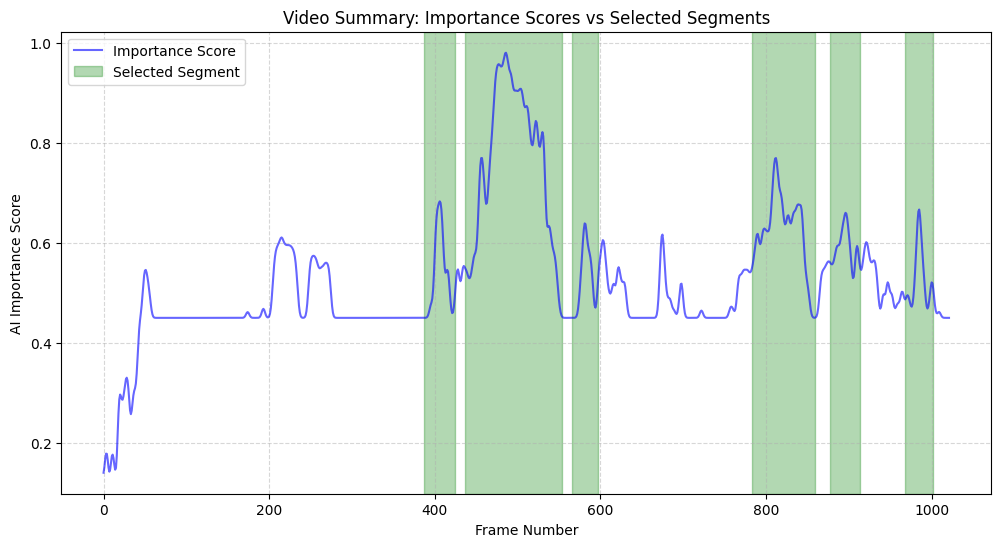

In [ ]:
import json
import matplotlib.pyplot as plt
import numpy as np


# Load the metadata JSON file
with open('/content/drive/MyDrive/output_multimodal/summary_meta.json', 'r') as f:
    data = json.load(f)

# Extract what we need
importance_scores = data["importance"]
frames = range(len(importance_scores))

# Plot as before...
plt.figure(figsize=(12, 6))
plt.plot(frames, importance_scores, label='Importance Score', color='blue', alpha=0.6)

for segment in data["segments"]:
    plt.axvspan(segment[0], segment[1], color='green', alpha=0.3,
                label='Selected Segment' if segment == data["segments"][0] else "")

plt.title("Video Summary: Importance Scores vs Selected Segments")
plt.xlabel("Frame Number")
plt.ylabel("AI Importance Score")
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# **DOCUMENTATION PART 2**

Video Summmary Visualization.

A graph is generated to show differeent segments of the summarized video.
The blue line shows the importance score and the green areas are the segments that were selected.

A data dictionary is created from the meta data json file, values for segment and importance are inputted manually.

Segments are the list of start frames and end frames. e.g. 387,424,
importance is on a scale of 0 to 1 gotten from the multimodel fusion class.


In [ ]:
import numpy as np

def calculate_metrics(ai_segments, gt_start_sec, gt_end_sec, fps, total_frames):

    # 1. Create bit-masks for the entire video length
    ai_mask = np.zeros(total_frames)
    gt_mask = np.zeros(total_frames)

    # 2. Fill AI mask (using your summary_meta.json data)
    for start, end in ai_segments:
        ai_mask[start:end+1] = 1

    # 3. Fill Ground Truth mask (converting AudioSet seconds to frames)
    gt_start_frame = int(gt_start_sec * fps)
    gt_end_frame = int(gt_end_sec * fps)
    gt_mask[gt_start_frame:gt_end_frame+1] = 1

    # 4. Calculate Overlap (Intersection)
    intersect = np.sum(np.logical_and(ai_mask, gt_mask))

    # 5. Calculate Metrics
    precision = intersect / np.sum(ai_mask) if np.sum(ai_mask) > 0 else 0
    recall = intersect / np.sum(gt_mask) if np.sum(gt_mask) > 0 else 0

    f1_score = 0
    if (precision + recall) > 0:
        f1_score = 2 * (precision * recall) / (precision + recall)

    return {
        "Precision": round(precision, 4),
        "Recall (Coverage)": round(recall, 4),
        "F1_Score": round(f1_score, 4),
        "Overlap_Frames": int(intersect)
    }

# ---  Usage ---
# Data from summary_meta.json
with open('/content/drive/MyDrive/output_multimodal/summary_meta.json', 'r') as f:
    summary_data = json.load(f)

# Extract what we need
ai_segs = summary_data["segments"]
total_f = summary_data["total_frames"]

fps_val = 30  # actual video FPS

# Ground truth: manually identified important event
audio_start = 25.0  # Event starts at 25 seconds
audio_end = 35.0    # Event ends at 35 seconds

results = calculate_metrics(ai_segs, audio_start, audio_end, fps_val, total_f)
print(results)

{'Precision': np.float64(0.4438), 'Recall (Coverage)': np.float64(0.5515), 'F1_Score': np.float64(0.4918), 'Overlap_Frames': 150}
